In [1]:
import pandas as pd
import numpy as np
import math
import matplotlib.pyplot as plt

# load data; filter by product and timeframe
file_name = ".\\r3_d0.csv"
df = pd.read_csv(file_name, delimiter=";")

# adjust low and high
low = 5000
high = 15000
df = df[df['timestamp'] >= low]
df = df[df['timestamp'] <= high]

df_vr = df[df['product'] == 'VOLCANIC_ROCK']
df_vr_9500 = df[df['product'] == 'VOLCANIC_ROCK_VOUCHER_9500']
df_vr_9750 = df[df['product'] == 'VOLCANIC_ROCK_VOUCHER_9750']
df_vr_10000 = df[df['product'] == 'VOLCANIC_ROCK_VOUCHER_10000']
df_vr_10250 = df[df['product'] == 'VOLCANIC_ROCK_VOUCHER_10250']
df_vr_10500 = df[df['product'] == 'VOLCANIC_ROCK_VOUCHER_10500']

In [2]:
# extract the 10500-strike fair values in the log

import re

def extract_fair_values(file_path):
    # (1) Read the file as a single string
    with open(file_path, "r", encoding="utf-8") as f:
        text = f.read()
    # DEBUG - print text to check
    # print(text[100000:110000])

    # (2) Find all occurrences of "\nfair_value: <number>"
    # This handles escaped \n inside logs
    pattern = r'\\nfair_value:\s*([0-9]*\.?[0-9]+)\\\\nOrders for\s+VOLCANIC_ROCK_VOUCHER_10500'
    # This pattern is faulty but if used won't require modulo for extracting 10500-strike options
    # pattern = pattern = r'\\nfair_value:\s*([0-9]*\.?[0-9]+)\s*\\nOrders for\s+VOLCANIC_ROCK_VOUCHER_10500'
    matches = re.findall(pattern, text)

    # (3) Convert to float list
    fv_10500 = [float(x) for x in matches]
    print(f"Extracted {len(fv_10500)} values for 10500-strike.")
    return fv_10500


# Example usage
file_path = "C:\\Users\\ishaa\\Downloads\\IMC-Prosperity-4\\p3_exploration\\backtests\\2026-04-02_11-48-03.log"
fv_10500 = extract_fair_values(file_path)

# Optional: print or inspect
print("First 10 10500-strike fair values:", fv_10500[:10])

Extracted 29271 values for 10500-strike.
First 10 10500-strike fair values: [94.135071, 93.838982, 91.627375, 90.169493, 93.099981, 90.414354, 87.818927, 85.237702, 80.503121, 84.128952]


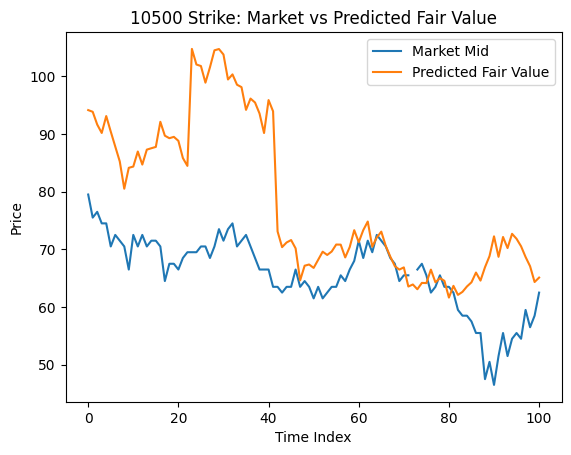

In [3]:
# plot the predicted price against the actual market

# --- Extract bid/ask ---
# Assuming columns are named like bid_price_1, ask_price_1
bids = df_vr_10500["bid_price_1"].values
asks = df_vr_10500["ask_price_1"].values

# Mid price is what you want to compare against fair value
mid_prices = (bids + asks) / 2

# Your predicted fair values (from previous extraction)
predicted = fv_10500  # make sure this is aligned length-wise

# --- Align lengths (important) ---
n = min(len(mid_prices), len(predicted))
mid_prices = mid_prices[:n]
bids = bids[:n]
asks = asks[:n]
predicted = predicted[:n]

# --- Plot ---
plt.figure()

plt.plot(mid_prices, label="Market Mid")
plt.plot(predicted, label="Predicted Fair Value")

# Optional: also visualize spread
# plt.plot(bids, linestyle="dashed", label="Best Bid")
# plt.plot(asks, linestyle="dashed", label="Best Ask")

plt.legend()
plt.title("10500 Strike: Market vs Predicted Fair Value")
plt.xlabel("Time Index")
plt.ylabel("Price")

plt.show()

In [4]:
# same as before, but for iv and avg_vol + avg_vol and predicted fair value

import re
import matplotlib.pyplot as plt

def extract_iv_avgvol_fair(file_path, strike="10500", product_prefix="VOLCANIC_ROCK_VOUCHER"):
    with open(file_path, "r", encoding="utf-8") as f:
        text = f.read()

    product_name = f"{product_prefix}_{strike}"

    # Match the exact log block:
    pattern = rf'\\\\niv:\s*([0-9]*\.?[0-9]+)\\\\navg_iv:\s*([0-9]*\.?[0-9]+)\\\\nfair_value:\s*([0-9]*\.?[0-9]+)\\\\nOrders for\s+{re.escape(product_name)}'

    matches = re.findall(pattern, text)
    print("len of matches =", len(matches))

    if not matches:
        print("No matches found.")
        print("Pattern used:")
        print(pattern)
        return [], [], []

    iv_list = [float(m[0]) for m in matches]
    avg_vol_list = [float(m[1]) for m in matches]
    fair_value_list = [float(m[2]) for m in matches]

    print(f"Extracted {len(matches)} rows for {product_name}.")
    return iv_list, avg_vol_list, fair_value_list


# --- usage ---
file_path = r"C:\\Users\\ishaa\\Downloads\\IMC-Prosperity-4\\p3_exploration\\backtests\\2026-04-02_14-54-15.log"
iv_10500, avg_vol_10500, fv_10500 = extract_iv_avgvol_fair(file_path, strike="10500")

print("First 5 iv:", iv_10500[:5])
print("First 5 avg_vol:", avg_vol_10500[:5])
print("First 5 fair values:", fv_10500[:5])

len of matches = 29271
Extracted 29271 rows for VOLCANIC_ROCK_VOUCHER_10500.
First 5 iv: [0.1668, 0.167227, 0.167578, 0.168357, 0.168504]
First 5 avg_vol: [0.167896, 0.167812, 0.167798, 0.167786, 0.167814]
First 5 fair values: [94.135098, 93.839006, 91.627407, 90.169525, 93.099999]


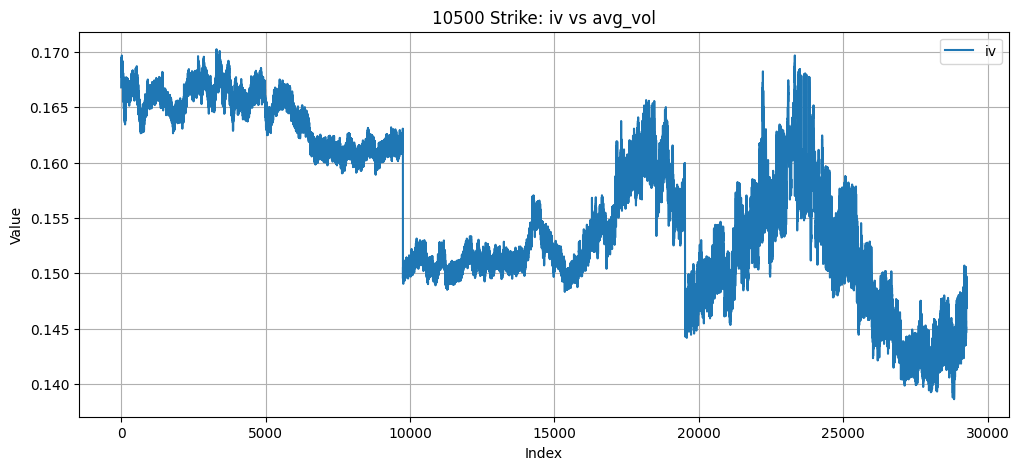

In [5]:

# --- plot avg_vol vs iv ---
n1 = min(len(iv_10500), len(avg_vol_10500))
x1 = range(n1)

plt.figure(figsize=(12, 5))
plt.plot(x1, iv_10500[:n1], label="iv")
# plt.plot(x1, avg_vol_10500[:n1], label="avg_vol")
plt.title("10500 Strike: iv vs avg_vol")
plt.xlabel("Index")
plt.ylabel("Value")
plt.legend()
plt.grid(True)
plt.show()

In [6]:
# --- plot avg_vol vs predicted fair values with two y-axes ---
# n2 = min(len(avg_vol_10500), len(fv_10500))
# x2 = range(n2)

# fig, ax1 = plt.subplots(figsize=(12, 5))

# ax1.plot(x2, avg_vol_10500[:n2], label="avg_vol")
# ax1.set_xlabel("Index")
# ax1.set_ylabel("avg_vol")

# ax2 = ax1.twinx()
# ax2.plot(x2, fv_10500[:n2], label="predicted fair value")
# ax2.set_ylabel("predicted fair value")

# lines1, labels1 = ax1.get_legend_handles_labels()
# lines2, labels2 = ax2.get_legend_handles_labels()
# ax1.legend(lines1 + lines2, labels1 + labels2, loc="best")

# plt.title("10500 Strike: avg_vol vs predicted fair value")
# plt.grid(True)
# plt.show()